# **Data Preparation and Cleaning**

In [150]:
# Importing Dataset
import pandas as pd

df_application_record = pd.read_csv("application_record.csv")
df_application_record.head()


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [151]:
import pandas as pd

df_credit_record = pd.read_csv("credit_record.csv")
df_credit_record.head()


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [152]:
# Making copy each table

df_application_record_cp = df_application_record.copy()
df_credit_record_cp = df_credit_record.copy()



In [153]:
# Data types check
df_application_record_cp.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [154]:
df_credit_record_cp.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [155]:
# Data types correction for 'ID' Column

df_application_record_cp['ID'] = df_application_record_cp['ID'].astype(str)
df_credit_record_cp['ID'] = df_credit_record_cp['ID'].astype(str)

df_application_record_cp['ID'].dtype





dtype('O')

In [156]:
df_credit_record_cp['ID'].dtype


dtype('O')

In [157]:
# Checking dtype & missing values for 'CNT_FAM_MEMBERS' Column
df_application_record_cp['CNT_FAM_MEMBERS'].dtype
df_application_record_cp['CNT_FAM_MEMBERS'].isna().sum()




np.int64(0)

In [158]:
df_application_record_cp['CNT_FAM_MEMBERS'].value_counts().head(10)

,count
CNT_FAM_MEMBERS,
2.0,233891
1.0,84492
3.0,77128
4.0,37356
5.0,5081
6.0,459
7.0,124
9.0,9
11.0,5


In [159]:
# Check if there is any value that not integer
non_integer = df_application_record_cp.loc[
    df_application_record_cp['CNT_FAM_MEMBERS'].notna() &
    (df_application_record_cp['CNT_FAM_MEMBERS'] % 1 != 0),
    'CNT_FAM_MEMBERS'
]

non_integer.head()


,CNT_FAM_MEMBERS


In [160]:
# Changing data type to Integer
df_application_record_cp['CNT_FAM_MEMBERS'] = (
    df_application_record_cp['CNT_FAM_MEMBERS']
    .astype('Int64')
)


df_application_record_cp['CNT_FAM_MEMBERS'].dtype



Int64Dtype()

In [161]:
df_application_record_cp['CNT_FAM_MEMBERS'].head()


,CNT_FAM_MEMBERS
0,2
1,2
2,2
3,1
4,1


In [162]:
# Make age column in years
df_application_record_cp['AGE_YEARS'] = (
    df_application_record_cp['DAYS_BIRTH'].abs() / 365
).round(0).astype('Int64')


In [163]:
df_application_record_cp[['DAYS_BIRTH', 'AGE_YEARS']].head()

,DAYS_BIRTH,AGE_YEARS
0,-12005,33
1,-12005,33
2,-21474,59
3,-19110,52
4,-19110,52


In [164]:
# Checking 'DAYS_EMPLOYED' Column
df_application_record_cp['DAYS_EMPLOYED'].describe()


,DAYS_EMPLOYED
count,438557.000000
mean,60563.675328
std,138767.799647
min,-17531.000000
25%,-3103.000000
50%,-1467.000000
75%,-371.000000
max,365243.000000


In [165]:
df_application_record_cp['IS_UNEMPLOYED'] = (
    df_application_record_cp['DAYS_EMPLOYED'] > 0
).astype(int)


In [166]:
# Changing Days Employed Column to years

import numpy as np

df_application_record_cp['EMPLOYED_YEARS'] = np.where(
    df_application_record_cp['DAYS_EMPLOYED'] < 0,
    (df_application_record_cp['DAYS_EMPLOYED'].abs() / 365),
    np.nan
)

df_application_record_cp['EMPLOYED_YEARS'] = (
    df_application_record_cp['EMPLOYED_YEARS']
    .round(1)
)

df_application_record_cp[['DAYS_EMPLOYED', 'IS_UNEMPLOYED', 'EMPLOYED_YEARS']].head(10)


,DAYS_EMPLOYED,IS_UNEMPLOYED,EMPLOYED_YEARS
0,-4542,0,12.4
1,-4542,0,12.4
2,-1134,0,3.1
3,-3051,0,8.4
4,-3051,0,8.4
5,-3051,0,8.4
6,-3051,0,8.4
7,365243,1,NaN
8,365243,1,NaN
9,365243,1,NaN


In [167]:
# Changing 'FLAG_OWN_CAR' and 'FLAG_OWN_REALTY' to 1/0 mapping
df_application_record_cp['OWN_CAR'] = (
    df_application_record_cp['FLAG_OWN_CAR']
    .map({'Y': 1, 'N': 0})
)

df_application_record_cp['OWN_REALTY'] = (
    df_application_record_cp['FLAG_OWN_REALTY']
    .map({'Y': 1, 'N': 0})
)




In [168]:
df_application_record_cp[['FLAG_OWN_CAR', 'OWN_CAR',
                            'FLAG_OWN_REALTY', 'OWN_REALTY']].head()


,FLAG_OWN_CAR,OWN_CAR,FLAG_OWN_REALTY,OWN_REALTY
0,Y,1,Y,1
1,Y,1,Y,1
2,Y,1,Y,1
3,N,0,Y,1
4,N,0,Y,1


In [169]:
# Changing 'ID' Column in credit_record table to string

df_credit_record_cp['ID'] = df_credit_record_cp['ID'].astype(str)
df_credit_record_cp['ID'].dtype

dtype('O')

In [170]:
df_credit_record_cp['ID'].head()


,ID
0,5001711
1,5001711
2,5001711
3,5001711
4,5001712


In [171]:
# Handling Missing Value in 'Occupation_Type' Column
df_application_record_cp['OCCUPATION_TYPE'] = (
    df_application_record_cp['OCCUPATION_TYPE']
    .fillna('Unknown')
)
df_application_record_cp['OCCUPATION_TYPE'].value_counts().head()



,count
OCCUPATION_TYPE,
Unknown,134203
Laborers,78240
Core staff,43007
Sales staff,41098
Managers,35487


In [172]:
df_application_record_cp['OCCUPATION_TYPE'].isna().sum()


np.int64(0)

In [173]:
df_application_record_cp.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  object 
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [174]:
df_credit_record_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  object
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(1), object(2)
memory usage: 24.0+ MB


In [175]:
df_application_record_cp.head(25)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE_YEARS,IS_UNEMPLOYED,EMPLOYED_YEARS,OWN_CAR,OWN_REALTY
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,0,0,Unknown,2,33,0,12.4,1,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,0,0,Unknown,2,33,0,12.4,1,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,0,0,Security staff,2,59,0,3.1,1,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,52,0,8.4,0,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,52,0,8.4,0,1
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,52,0,8.4,0,1
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,52,0,8.4,0,1
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,0,0,Unknown,1,62,1,NaN,0,1
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,0,0,Unknown,1,62,1,NaN,0,1
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,0,0,Unknown,1,62,1,NaN,0,1


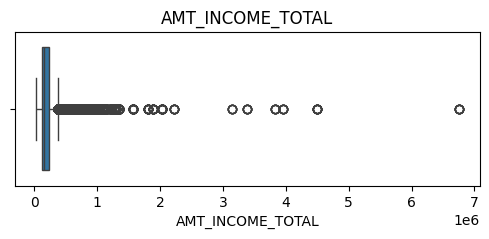

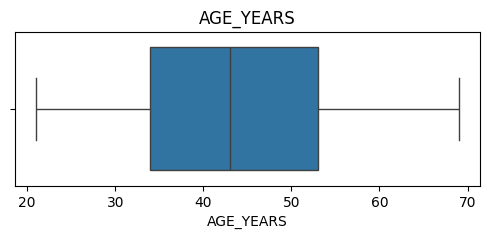

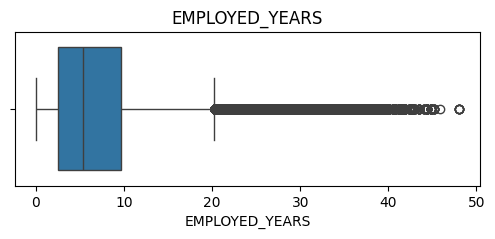

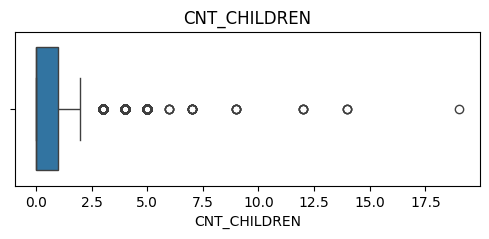

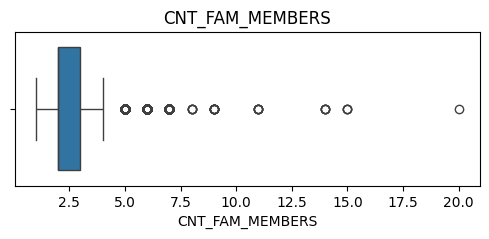

In [176]:
# Outlier Checking

num_cols_app = [
    'AMT_INCOME_TOTAL',
    'AGE_YEARS',
    'EMPLOYED_YEARS',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS'
]

import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols_app:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df_application_record_cp[col])
    plt.title(col)
    plt.show()



# **EDA for 'application_record' Table**

In [177]:
# Dataset Size & Structure
df_application_record_cp.shape


(438557, 23)

In [178]:
# General Information
df_application_record_cp.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  object 
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [179]:
# Missing Value Overview
df_application_record_cp.isna().sum().sort_values(ascending=False)


,0
EMPLOYED_YEARS,75329
CODE_GENDER,0
ID,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
FLAG_OWN_CAR,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_HOUSING_TYPE,0


In [180]:
# Descriptive Statistics of Numerical Variables

num_cols = [
    'AMT_INCOME_TOTAL',
    'AGE_YEARS',
    'EMPLOYED_YEARS',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS'
]

df_application_record_cp[num_cols].describe()


,AMT_INCOME_TOTAL,AGE_YEARS,EMPLOYED_YEARS,CNT_CHILDREN,CNT_FAM_MEMBERS
count,4.385570e+05,438557.0,363228.000000,438557.000000,438557.0
mean,1.875243e+05,43.83396,7.186540,0.427390,2.194465
std,1.100869e+05,11.472765,6.574301,0.724882,0.897207
min,2.610000e+04,21.0,0.000000,0.000000,1.0
25%,1.215000e+05,34.0,2.500000,0.000000,2.0
50%,1.607805e+05,43.0,5.300000,0.000000,2.0
75%,2.250000e+05,53.0,9.600000,1.000000,3.0
max,6.750000e+06,69.0,48.000000,19.000000,20.0


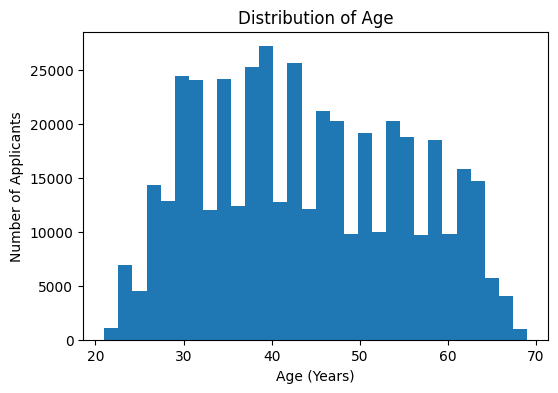

In [181]:
# Age Distribution
plt.figure(figsize=(6,4))
plt.hist(df_application_record_cp['AGE_YEARS'], bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Applicants')
plt.show()


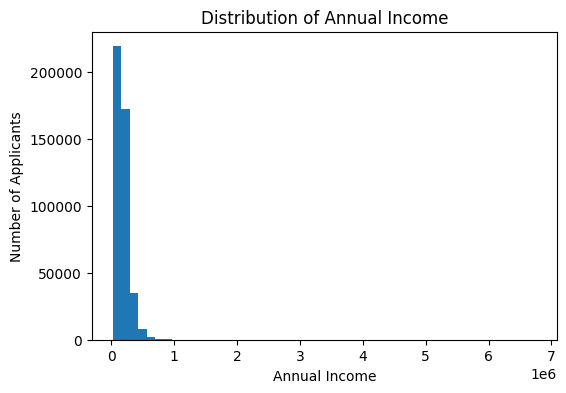

In [182]:
# Income Distribution
plt.figure(figsize=(6,4))
plt.hist(df_application_record_cp['AMT_INCOME_TOTAL'], bins=50)
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Number of Applicants')
plt.show()



In [183]:
# Asset Ownership (Car & Real Estate)
df_application_record_cp[['OWN_CAR', 'OWN_REALTY']].mean()


,0
OWN_CAR,0.371897
OWN_REALTY,0.693351


In [184]:
# Education Level Composition
df_application_record_cp['NAME_EDUCATION_TYPE'].value_counts(normalize=True)


,proportion
NAME_EDUCATION_TYPE,
Secondary / secondary special,0.688214
Higher education,0.267974
Incomplete higher,0.033863
Lower secondary,0.009237
Academic degree,0.000711


In [185]:
# Occupation Categories

df_application_record_cp['OCCUPATION_TYPE'].value_counts().head(10)


,count
OCCUPATION_TYPE,
Unknown,134203
Laborers,78240
Core staff,43007
Sales staff,41098
Managers,35487
Drivers,26090
High skill tech staff,17289
Accountants,15985
Medicine staff,13520


In [186]:
# Household Index
df_application_record_cp['CNT_FAM_MEMBERS'].value_counts().sort_index()



,count
CNT_FAM_MEMBERS,
1,84492
2,233891
3,77128
4,37356
5,5081
6,459
7,124
8,4
9,9


# **EDA for 'credit_record' Table**

In [187]:
# Dataset Size and Structure
df_credit_record_cp.shape


(1048575, 3)

In [188]:
# General Information & Data Types
df_credit_record_cp.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  object
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(1), object(2)
memory usage: 24.0+ MB


In [189]:
# Number of Unique Customers
df_credit_record_cp['ID'].nunique()


45985

In [190]:
# Distribution of Credit Status
df_credit_record_cp['STATUS'].value_counts()


,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [191]:
# Proportion of Credit Status Categories
df_credit_record_cp['STATUS'].value_counts(normalize=True)


,proportion
STATUS,
C,0.421554
0,0.365372
X,0.199537
1,0.010576
5,0.001615
2,0.000828
3,0.000305
4,0.000213


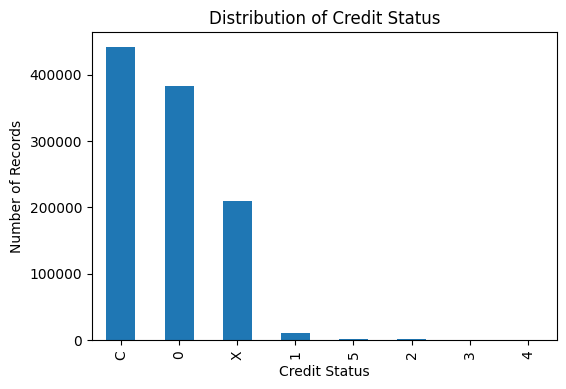

In [192]:
# Visual Distribution of Credit Status
import matplotlib.pyplot as plt

df_credit_record_cp['STATUS'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title('Distribution of Credit Status')
plt.xlabel('Credit Status')
plt.ylabel('Number of Records')
plt.show()


In [193]:
# Time Coverage of Credit Records
df_credit_record_cp['MONTHS_BALANCE'].describe()


,MONTHS_BALANCE
count,1.048575e+06
mean,-1.913700e+01
std,1.402350e+01
min,-6.000000e+01
25%,-2.900000e+01
50%,-1.700000e+01
75%,-7.000000e+00
max,0.000000e+00


In [194]:
# Credit History Length per Customer
credit_history_length = (
    df_credit_record_cp
    .groupby('ID')['MONTHS_BALANCE']
    .count()
)

credit_history_length.describe()


,MONTHS_BALANCE
count,45985.000000
mean,22.802544
std,15.492771
min,1.000000
25%,10.000000
50%,19.000000
75%,34.000000
max,61.000000


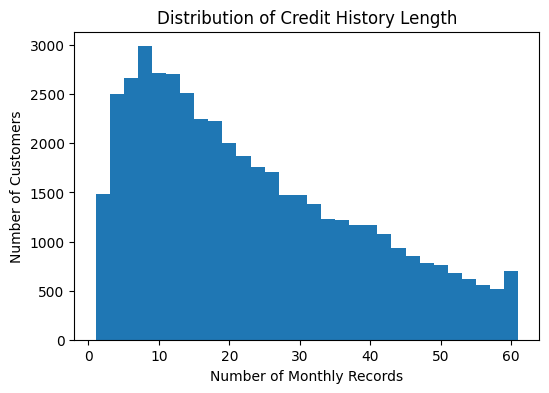

In [195]:
# Visual Distribution of Credit History Length
plt.figure(figsize=(6,4))
plt.hist(credit_history_length, bins=30)
plt.title('Distribution of Credit History Length')
plt.xlabel('Number of Monthly Records')
plt.ylabel('Number of Customers')
plt.show()


In [196]:
df_application_record_cl = df_application_record_cp.copy()
df_credit_record_cl = df_credit_record_cp.copy()

# **Advanced Analysis**

In [197]:
# Making Default Category per Customer from Credit Record Table

df_credit_record_cl['IS_DEFAULT'] = (
    df_credit_record_cl['STATUS'].isin(['3', '4', '5'])
).astype(int)

# The worst observed credit status across all months is used to assign a single default label to each customer.
default_per_id = (
    df_credit_record_cl
    .groupby('ID', as_index=False)['IS_DEFAULT']
    .max()
)

# Default Distribution
default_per_id['IS_DEFAULT'].value_counts(normalize=True)


,proportion
IS_DEFAULT,
0,0.992802
1,0.007198


In [198]:
# Rename default column

default_per_id = default_per_id.rename(columns={'IS_DEFAULT': 'DEFAULT_FLAG'})

default_per_id.head(20)

,ID,DEFAULT_FLAG
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0
5,5001717,0
6,5001718,0
7,5001719,0
8,5001720,0
9,5001723,0


In [199]:
# Table Join Application Record and Default Table per ID

df_application_record_cl['ID'] = df_application_record_cl['ID'].astype(str)
default_per_id['ID'] = default_per_id['ID'].astype(str)

# Left Join
df_final = df_application_record_cl.merge(
    default_per_id,
    on='ID',
    how='left'
)

df_final.shape



(438557, 24)

In [200]:
df_final['DEFAULT_FLAG'].isna().sum()


np.int64(402100)

In [201]:
# Final Join Table
df_final = df_final.dropna(subset=['DEFAULT_FLAG'])
df_final['DEFAULT_FLAG'] = df_final['DEFAULT_FLAG'].astype(int)

df_final.head(20)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE_YEARS,IS_UNEMPLOYED,EMPLOYED_YEARS,OWN_CAR,OWN_REALTY,DEFAULT_FLAG
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,0,Unknown,2,33,0,12.4,1,1,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,0,Unknown,2,33,0,12.4,1,1,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,0,Security staff,2,59,0,3.1,1,1,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,1,Sales staff,1,52,0,8.4,0,1,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,1,Sales staff,1,52,0,8.4,0,1,0
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,1,Sales staff,1,52,0,8.4,0,1,0
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,1,Sales staff,1,52,0,8.4,0,1,0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,0,Unknown,1,62,1,NaN,0,1,0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,0,Unknown,1,62,1,NaN,0,1,0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,0,Unknown,1,62,1,NaN,0,1,0


# **Comparative EDA Based on 'Good' or 'Bad' Customers**

In [202]:
# Separating between 'Good' and 'Bad' Customers
good = df_final[df_final['DEFAULT_FLAG'] == 0]
bad  = df_final[df_final['DEFAULT_FLAG'] == 1]


In [203]:
# Numerical Variables Comparison

num_cols = ['AMT_INCOME_TOTAL', 'AGE_YEARS', 'EMPLOYED_YEARS',
            'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

good[num_cols].median(), bad[num_cols].median()


(AMT_INCOME_TOTAL    157500.0
 AGE_YEARS               43.0
 EMPLOYED_YEARS           5.5
 CNT_CHILDREN             0.0
 CNT_FAM_MEMBERS          2.0
 dtype: Float64,
 AMT_INCOME_TOTAL    180000.0
 AGE_YEARS               45.0
 EMPLOYED_YEARS           4.0
 CNT_CHILDREN             0.0
 CNT_FAM_MEMBERS          2.0
 dtype: Float64)

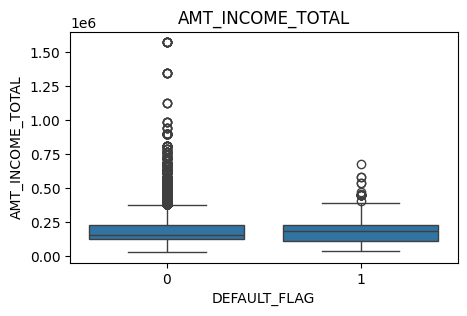

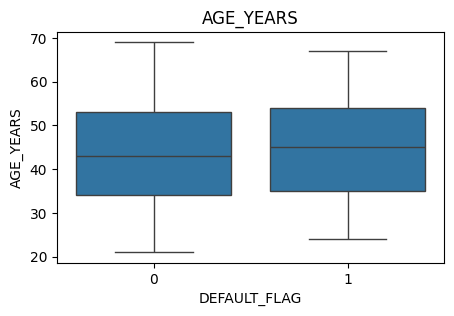

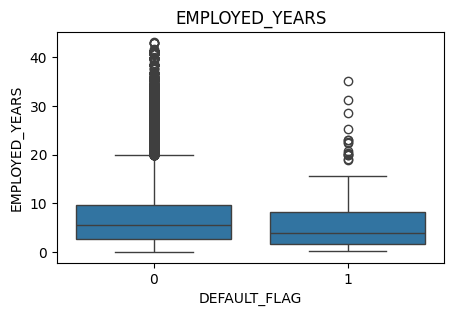

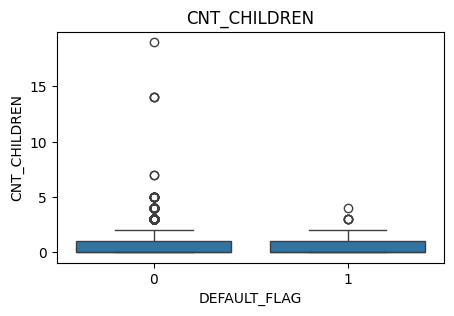

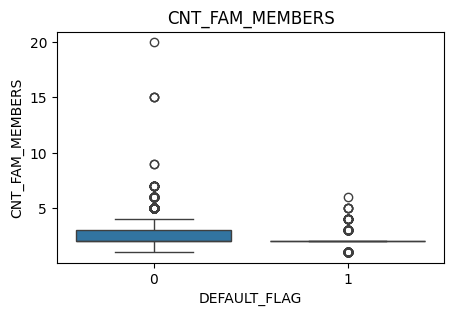

In [204]:
# Visual Comparison
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='DEFAULT_FLAG', y=col, data=df_final)
    plt.title(col)
    plt.show()


# **Default Rate Based by Key Segments**

**Income**

In [205]:
df_final['income_bin'] = pd.qcut(df_final['AMT_INCOME_TOTAL'], 4, labels=['Low','Mid','High','Very High'])
df_final.groupby('income_bin')['DEFAULT_FLAG'].mean()


/tmp/ipython-input-2200181241.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby('income_bin')['DEFAULT_FLAG'].mean()


,DEFAULT_FLAG
income_bin,
Low,0.008730
Mid,0.006325
High,0.009778
Very High,0.008109


**Employment**

In [206]:
df_final.groupby('IS_UNEMPLOYED')['DEFAULT_FLAG'].mean()


,DEFAULT_FLAG
IS_UNEMPLOYED,
0,0.007849
1,0.010432


**Family Size**

In [207]:
df_final.groupby('CNT_FAM_MEMBERS')['DEFAULT_FLAG'].mean()


,DEFAULT_FLAG
CNT_FAM_MEMBERS,
1,0.010448
2,0.008067
3,0.007320
4,0.006439
5,0.010076
6,0.017241
7,0.000000
9,0.000000
15,0.000000


**Categorical Variables**

In [208]:
# Education
df_final.groupby('NAME_EDUCATION_TYPE')['DEFAULT_FLAG'].mean().sort_values(ascending=False)


,DEFAULT_FLAG
NAME_EDUCATION_TYPE,
Lower secondary,0.018717
Incomplete higher,0.014184
Higher education,0.009225
Secondary / secondary special,0.007426
Academic degree,0.000000


In [209]:
# Occupation
df_final.groupby('OCCUPATION_TYPE')['DEFAULT_FLAG'].mean().sort_values(ascending=False).head(10)


,DEFAULT_FLAG
OCCUPATION_TYPE,
IT staff,0.033333
Security staff,0.015203
Core staff,0.013645
Secretaries,0.013245
Waiters/barmen staff,0.011494
Low-skill Laborers,0.011429
High skill tech staff,0.009400
Unknown,0.008743
Laborers,0.007728


# **Risk Table Based on Income, Employment, and Family Size**

In [210]:
# Making Segmentation

# Income segmentation (quartile)
df_final['income_segment'] = pd.qcut(
    df_final['AMT_INCOME_TOTAL'],
    q=4,
    labels=['Low', 'Mid', 'High', 'Very High']
)

# Family burden segmentation
df_final['family_segment'] = pd.cut(
    df_final['CNT_FAM_MEMBERS'],
    bins=[0,2,4,20],
    labels=['Small', 'Medium', 'Large']
)

# Employment status already exists
# IS_UNEMPLOYED: 1 = Unemployed, 0 = Employed
df_final['employment_segment'] = df_final['IS_UNEMPLOYED'].map({0:'Employed', 1:'Unemployed'})


In [211]:
# Creating the risk table

risk_table = (
    df_final
    .groupby(['income_segment', 'employment_segment', 'family_segment'])
    .agg(
        applicants = ('ID','count'),
        default_rate = ('DEFAULT_FLAG','mean')
    )
    .reset_index()
    .sort_values('default_rate', ascending=False)
)

risk_table.head(20)


/tmp/ipython-input-2537827131.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['income_segment', 'employment_segment', 'family_segment'])


,income_segment,employment_segment,family_segment,applicants,default_rate
2,Low,Employed,Large,115,0.034783
3,Low,Unemployed,Small,2541,0.015742
15,High,Unemployed,Small,1318,0.013657
12,High,Employed,Small,5972,0.009545
18,Very High,Employed,Small,4967,0.009261
13,High,Employed,Medium,2667,0.008624
7,Mid,Employed,Medium,2389,0.007953
14,High,Employed,Large,135,0.007407
19,Very High,Employed,Medium,2115,0.007092
6,Mid,Employed,Small,5096,0.006868


# **Hypothesis Testing**

**H1 — Income & Employment vs Default**

In [212]:
# Test A Income (Low vs High)
from scipy.stats import mannwhitneyu

low_income = df_final[df_final['income_segment']=='Low']['DEFAULT_FLAG']
high_income = df_final[df_final['income_segment']=='Very High']['DEFAULT_FLAG']

mannwhitneyu(low_income, high_income)


MannwhitneyuResult(statistic=np.float64(36509758.0), pvalue=np.float64(0.6583287472530288))

In [213]:
# Test B Employment
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df_final['IS_UNEMPLOYED'], df_final['DEFAULT_FLAG'])
chi2_contingency(contingency)


Chi2ContingencyResult(statistic=np.float64(3.835183154274147), pvalue=np.float64(0.05018750755300367), dof=1, expected_freq=array([[30070.82069287,   251.17930713],
       [ 6084.17930713,    50.82069287]]))

**H2 - Asset Ownership**

In [214]:
# Real Estate

pd.crosstab(df_final['FLAG_OWN_REALTY'], df_final['DEFAULT_FLAG'], normalize='index')


DEFAULT_FLAG,0,1
FLAG_OWN_REALTY,,
N,0.989792,0.010208
Y,0.992655,0.007345


In [215]:
chi2_contingency(pd.crosstab(df_final['FLAG_OWN_REALTY'], df_final['DEFAULT_FLAG']))


Chi2ContingencyResult(statistic=np.float64(7.67183493275242), pvalue=np.float64(0.005608938968180889), dof=1, expected_freq=array([[11852.00112461,    98.99887539],
       [24302.99887539,   203.00112461]]))

**H3 - Household Size**

In [216]:
from scipy.stats import mannwhitneyu

small = df_final[df_final['family_segment']=='Small']['DEFAULT_FLAG']
large = df_final[df_final['family_segment']=='Large']['DEFAULT_FLAG']

mannwhitneyu(small, large)


MannwhitneyuResult(statistic=np.float64(6337075.0), pvalue=np.float64(0.6878656795545088))

# **Exporting Tables to csv**

In [217]:
final_applicant_table = df_final.copy()



In [219]:

# ID as string
df_final['ID'] = df_final['ID'].astype(str)

# Default flag as int (0/1)
df_final['DEFAULT_FLAG'] = df_final['DEFAULT_FLAG'].astype(int)

# Making sure numeric columns are numeric
num_cols = ['AMT_INCOME_TOTAL','AGE_YEARS','EMPLOYED_YEARS','CNT_CHILDREN','CNT_FAM_MEMBERS','IS_UNEMPLOYED']
for c in num_cols:
    if c in df_final.columns:
        df_final[c] = pd.to_numeric(df_final[c], errors='coerce')


In [220]:
# Income segment (quartile)
df_final['income_segment'] = pd.qcut(
    df_final['AMT_INCOME_TOTAL'],
    q=4,
    labels=['Low', 'Mid', 'High', 'Very High']
)

# Employment segment from IS_UNEMPLOYED (0=Employed, 1=Unemployed)
df_final['employment_segment'] = df_final['IS_UNEMPLOYED'].map({0: 'Employed', 1: 'Unemployed'})

# Family segment (tune bins as needed)
df_final['family_segment'] = pd.cut(
    df_final['CNT_FAM_MEMBERS'],
    bins=[0, 2, 4, 20],
    labels=['Small', 'Medium', 'Large'],
    include_lowest=True
)


In [221]:
# Output tables
def risk_by(col):
    return (
        df_final
        .groupby(col, dropna=False)
        .agg(
            applicants=('ID','count'),
            default_rate=('DEFAULT_FLAG','mean')
        )
        .reset_index()
        .sort_values('default_rate', ascending=False)
    )

risk_by_income = risk_by('income_segment')
risk_by_employment = risk_by('employment_segment')
risk_by_family = risk_by('family_segment')
risk_by_education = risk_by('NAME_EDUCATION_TYPE')
risk_by_occupation = risk_by('OCCUPATION_TYPE')


/tmp/ipython-input-1822264396.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col, dropna=False)
/tmp/ipython-input-1822264396.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col, dropna=False)


In [222]:
risk_matrix = (
    df_final
    .groupby(['income_segment','employment_segment','family_segment'], dropna=False)
    .agg(
        applicants=('ID','count'),
        default_rate=('DEFAULT_FLAG','mean')
    )
    .reset_index()
    .sort_values('default_rate', ascending=False)
)


/tmp/ipython-input-3280273239.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['income_segment','employment_segment','family_segment'], dropna=False)


In [223]:
final_applicant_table.to_csv("final_applicant_table.csv", index=False, sep=',', encoding='utf-8-sig')
risk_matrix.to_csv("risk_matrix.csv", index=False, sep=',', encoding='utf-8-sig')

risk_by_income.to_csv("risk_by_income.csv", index=False, sep=',', encoding='utf-8-sig')
risk_by_employment.to_csv("risk_by_employment.csv", index=False, sep=',', encoding='utf-8-sig')
risk_by_family.to_csv("risk_by_family.csv", index=False, sep=',', encoding='utf-8-sig')
risk_by_education.to_csv("risk_by_education.csv", index=False, sep=',', encoding='utf-8-sig')
risk_by_occupation.to_csv("risk_by_occupation.csv", index=False, sep=',', encoding='utf-8-sig')
